# Combination Model Evaluation

This notebook reproduces the final evaluation of the weighted combination model.

In [1]:
# Evaluate the final weighted combination model
from pathlib import Path
import json
import os
import warnings


warnings.filterwarnings("ignore", message="IProgress not found.*")

BASE_DIR = next(
    candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "Models").exists() and (candidate / "Dataset source").exists()
)
DATASET_PATH = BASE_DIR / "Dataset source" / "training" / "Dataset_SMS_clean.csv"
CONFIG_PATH = BASE_DIR / "Models" / "combination_model" / "config.json"
MODEL_CACHE_DIR = BASE_DIR / "local_artifacts" / "huggingface" / "models"

os.environ.setdefault("HF_HOME", str(MODEL_CACHE_DIR / "home"))
os.environ.setdefault("HF_HUB_CACHE", str(MODEL_CACHE_DIR / "hub"))
os.environ.setdefault("HF_XET_CACHE", str(MODEL_CACHE_DIR / "xet"))
os.environ.setdefault("HF_HUB_DISABLE_XET", "1")

import joblib
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from transformers import AutoModelForSequenceClassification, AutoTokenizer


TEST_SIZE = 0.2
VALIDATION_SIZE_FROM_HOLDOUT = 0.5
RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32 if DEVICE.type == "cuda" else 16

with open(CONFIG_PATH, "r", encoding="utf-8") as config_file:
    combination_config = json.load(config_file)

WEIGHTS = {
    model_name: float(model_weight)
    for model_name, model_weight in combination_config["weights"].items()
}
THRESHOLD = float(combination_config["threshold"])
MAX_LENGTH = int(combination_config.get("max_length", 160))


def resolve_model_path(model_path_text):
    model_path = Path(model_path_text)
    return model_path if model_path.is_absolute() else BASE_DIR / model_path


SVM_MODEL_PATH = resolve_model_path(combination_config["models"]["svm"])
LOGREG_MODEL_PATH = resolve_model_path(combination_config["models"]["logistic_regression"])
XLMR_MODEL_PATH = resolve_model_path(combination_config["models"]["xlm_roberta"])

# Reproduce the train/validation/test split used when the combination weights were selected.
evaluation_df = pd.read_csv(DATASET_PATH, encoding="utf-8-sig")
evaluation_df = evaluation_df.dropna(subset=["Category", "Message"]).copy()
evaluation_df["Category"] = evaluation_df["Category"].astype(str).str.strip().str.lower()
evaluation_df["Message"] = evaluation_df["Message"].astype(str).str.strip()
evaluation_df = evaluation_df[evaluation_df["Category"].isin(["ham", "spam"])]
evaluation_df = evaluation_df[evaluation_df["Message"] != ""]

x_final_train, x_holdout, y_final_train, y_holdout = train_test_split(
    evaluation_df["Message"],
    evaluation_df["Category"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=evaluation_df["Category"],
)
x_validation, x_final_test, y_validation, y_final_test = train_test_split(
    x_holdout,
    y_holdout,
    test_size=VALIDATION_SIZE_FROM_HOLDOUT,
    random_state=RANDOM_STATE,
    stratify=y_holdout,
)


def sigmoid(values):
    values = np.asarray(values, dtype=float)
    positive = values >= 0
    probabilities = np.empty_like(values, dtype=float)
    probabilities[positive] = 1.0 / (1.0 + np.exp(-values[positive]))
    exp_values = np.exp(values[~positive])
    probabilities[~positive] = exp_values / (1.0 + exp_values)
    return probabilities


def classical_spam_probabilities(model, messages):
    message_list = [str(message) for message in messages]
    classes = [str(label).lower() for label in model.classes_]
    spam_index = classes.index("spam")

    if hasattr(model, "predict_proba"):
        return model.predict_proba(message_list)[:, spam_index].astype(float)

    decision_scores = np.asarray(model.decision_function(message_list), dtype=float)
    if decision_scores.ndim > 1:
        return sigmoid(decision_scores[:, spam_index])

    probabilities = sigmoid(decision_scores)
    if len(classes) >= 2 and classes[1] != "spam":
        probabilities = 1.0 - probabilities
    return probabilities.astype(float)


svm_model = joblib.load(SVM_MODEL_PATH)
logreg_model = joblib.load(LOGREG_MODEL_PATH)
xlmr_tokenizer = AutoTokenizer.from_pretrained(XLMR_MODEL_PATH, local_files_only=True)
xlmr_model = AutoModelForSequenceClassification.from_pretrained(XLMR_MODEL_PATH, local_files_only=True)
xlmr_model.to(DEVICE)
xlmr_model.eval()
xlmr_id2label = {
    int(index): str(label).lower()
    for index, label in xlmr_model.config.id2label.items()
}
xlmr_spam_index = next(index for index, label in xlmr_id2label.items() if label == "spam")


@torch.inference_mode()
def xlmr_spam_probabilities(messages):
    probabilities = []
    message_list = [str(message) for message in messages]
    for start in range(0, len(message_list), BATCH_SIZE):
        batch_messages = message_list[start:start + BATCH_SIZE]
        inputs = xlmr_tokenizer(
            batch_messages,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        inputs = {key: value.to(DEVICE) for key, value in inputs.items()}
        batch_probabilities = torch.softmax(xlmr_model(**inputs).logits, dim=-1)
        probabilities.extend(
            batch_probabilities[:, xlmr_spam_index].detach().cpu().numpy().tolist()
        )
    return np.asarray(probabilities, dtype=float)


def combination_spam_probabilities(messages):
    return (
        WEIGHTS["svm"] * classical_spam_probabilities(svm_model, messages)
        + WEIGHTS["logistic_regression"] * classical_spam_probabilities(logreg_model, messages)
        + WEIGHTS["xlm_roberta"] * xlmr_spam_probabilities(messages)
    )


def probabilities_to_labels(probabilities):
    return np.where(probabilities >= THRESHOLD, "spam", "ham")


print("Calculating combination-model probabilities...")
train_spam_probabilities = combination_spam_probabilities(x_final_train.tolist())
test_spam_probabilities = combination_spam_probabilities(x_final_test.tolist())
final_train_predictions = probabilities_to_labels(train_spam_probabilities)
final_test_predictions = probabilities_to_labels(test_spam_probabilities)

final_train_accuracy = accuracy_score(y_final_train, final_train_predictions)
final_test_accuracy = accuracy_score(y_final_test, final_test_predictions)
final_report_df = pd.DataFrame(
    classification_report(
        y_final_test,
        final_test_predictions,
        labels=["ham", "spam"],
        output_dict=True,
        zero_division=0,
    )
).transpose()

# Compare the reproduced results with the metrics saved during weight selection.
expected_test_metrics = combination_config["metrics"]["combination_model"]["test"]
observed_test_metrics = {
    "accuracy": final_test_accuracy,
    "spam_precision": final_report_df.loc["spam", "precision"],
    "spam_recall": final_report_df.loc["spam", "recall"],
    "spam_f1": final_report_df.loc["spam", "f1-score"],
}
metric_comparison_df = pd.DataFrame(
    {
        "Saved in config": {
            metric_name: expected_test_metrics[metric_name]
            for metric_name in observed_test_metrics
        },
        "Reproduced now": observed_test_metrics,
    }
)
metric_comparison_df["Difference"] = (
    metric_comparison_df["Reproduced now"] - metric_comparison_df["Saved in config"]
)
saved_metrics_reproduced = bool(
    np.allclose(
        metric_comparison_df["Saved in config"],
        metric_comparison_df["Reproduced now"],
        atol=1e-12,
    )
)

print(f"Device: {DEVICE}")
print(f"Weights: SVM={WEIGHTS['svm']:.2f}, Logistic Regression={WEIGHTS['logistic_regression']:.2f}, XLM-RoBERTa={WEIGHTS['xlm_roberta']:.2f}")
print(f"Classification threshold: {THRESHOLD:.2f}")
print(f"Training messages: {len(x_final_train)}")
print(f"Validation messages excluded from final evaluation: {len(x_validation)}")
print(f"Final evaluation messages: {len(x_final_test)}")
print(f"Training accuracy: {final_train_accuracy:.4f}")
print(f"Final evaluation accuracy: {final_test_accuracy:.4f}")
display(final_report_df)
print(f"Saved configuration metrics reproduced exactly: {saved_metrics_reproduced}")
display(metric_comparison_df)


Calculating combination-model probabilities...


Device: cuda
Weights: SVM=0.35, Logistic Regression=0.15, XLM-RoBERTa=0.50
Classification threshold: 0.50
Training messages: 4120
Validation messages excluded from final evaluation: 515
Final evaluation messages: 516
Training accuracy: 0.9985
Final evaluation accuracy: 0.9922


,precision,recall,f1-score,support
ham,0.993392,0.997788,0.995585,452.000000
spam,0.983871,0.953125,0.968254,64.000000
accuracy,0.992248,0.992248,0.992248,0.992248
macro avg,0.988632,0.975456,0.981919,516.000000
weighted avg,0.992211,0.992248,0.992195,516.000000


Saved configuration metrics reproduced exactly: False


,Saved in config,Reproduced now,Difference
accuracy,0.986434,0.992248,0.005814
spam_precision,0.938462,0.983871,0.045409
spam_recall,0.953125,0.953125,0.000000
spam_f1,0.945736,0.968254,0.022518


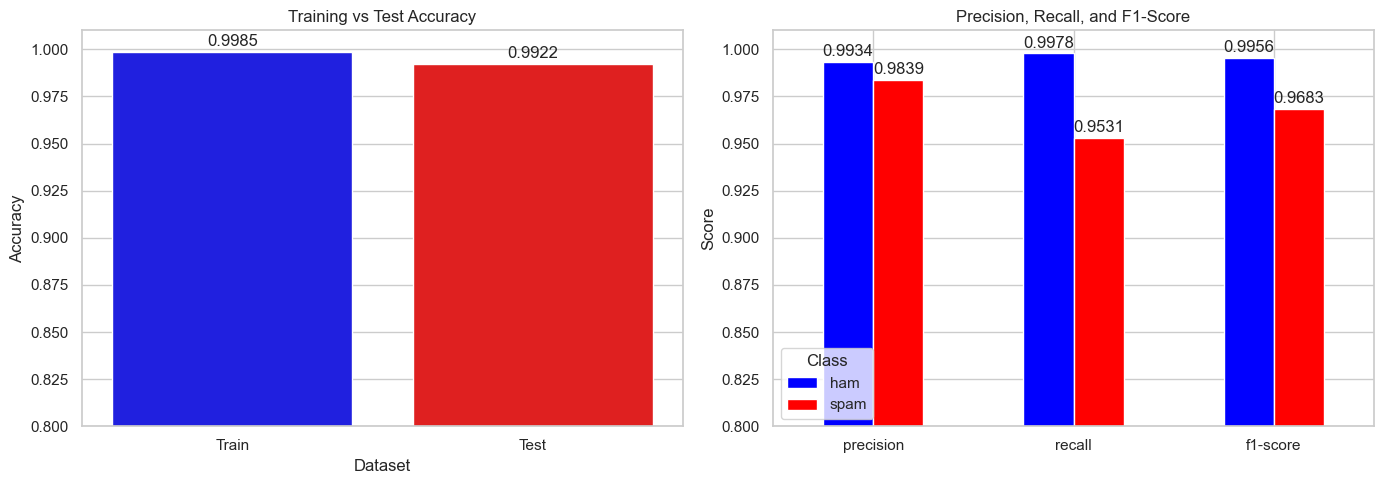

Saved figure: D:\Project\Leeds\Msc Project\figure\figure_4_4_combination_model_performance.png


In [2]:
# Generate the dissertation performance figure
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


FIGURE_PATH = BASE_DIR / "figure" / "figure_4_4_combination_model_performance.png"
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
accuracy_df = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [final_train_accuracy, final_test_accuracy],
})
sns.barplot(
    data=accuracy_df,
    x="Dataset",
    y="Accuracy",
    hue="Dataset",
    palette=["blue", "red"],
    ax=axes[0],
    legend=False,
)
score_ticks = np.arange(0.8, 1.0001, 0.025)
axes[0].set_ylim(0.8, 1.01)
axes[0].set_yticks(score_ticks)
axes[0].set_title("Training vs Test Accuracy")
axes[0].set_ylabel("Accuracy")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.4f", padding=2)

metrics_df = final_report_df.loc[
    ["ham", "spam"],
    ["precision", "recall", "f1-score"],
].transpose()
metrics_df.plot(kind="bar", ax=axes[1], color=["blue", "red"])
axes[1].set_ylim(0.8, 1.01)
axes[1].set_yticks(score_ticks)
axes[1].set_title("Precision, Recall, and F1-Score")
axes[1].set_ylabel("Score")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Class")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.4f", padding=2)

plt.tight_layout()
FIGURE_PATH.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print(f"Saved figure: {FIGURE_PATH}")
